In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

In [ ]:
filename = "geeks.png"
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

array([[106, 106, 106, ..., 106, 106, 106],
       [106, 106, 106, ..., 106, 106, 106],
       [106, 106, 106, ..., 106, 106, 106],
       ...,
       [ 88,  88,  88, ..., 106, 106, 106],
       [ 88,  88,  88, ..., 106, 106, 106],
       [ 88,  88,  88, ..., 106, 106, 106]], dtype=uint8)
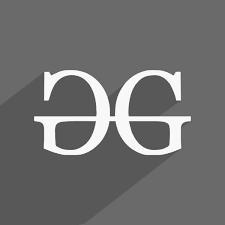

In [ ]:
image

In [ ]:
# stimulate degradation (motion blur + noise)

#motion blur
kernel_size = 15
kernel_motion_blur = np.zeros((kernel_size, kernel_size))
kernel_motion_blur[int((kernel_size-1)/2),:] = np.ones(kernel_size)
kernel_motion_blur = kernel_motion_blur / kernel_size

In [ ]:
# apply motion blur
blurred = cv2.filter2D(image, -1, kernel_motion_blur)


In [ ]:
# add gaussian noise
noisy_blurred = blurred + 20 * np.random.randn(*blurred.shape)
noisy_blurred = np.clip(noisy_blurred, 0, 255).astype(np.uint8)

In [ ]:
# Restoration technique

# Wiener Method
wiener_restored = wiener(noisy_blurred)

In [ ]:
# inverse filtering
# convert frequency domain

f = np.fft.fft2(noisy_blurred)
H = np.fft.fft2(kernel_motion_blur,s=image.shape)
H_conj = np.conj(H)
H_abs = np.abs(H)**2
epsilon = 1e-5              #avoid division by zero

In [ ]:
inverse_filter = H_conj / (H_abs + epsilon)
restored_freq = f * inverse_filter
inverse_restored = np.abs(np.fft.ifft2(restored_freq))


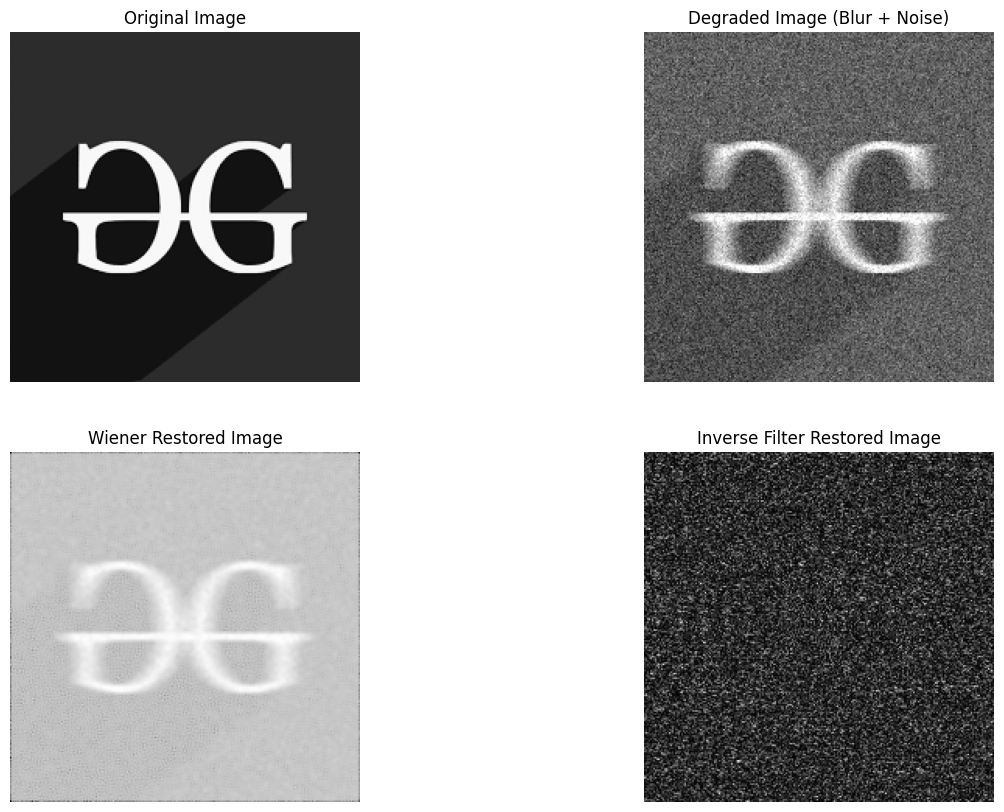

In [ ]:
# Display image

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(noisy_blurred, cmap='gray')
plt.title("Degraded Image (Blur + Noise)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(wiener_restored, cmap='gray')
plt.title("Wiener Restored Image")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(inverse_restored, cmap='gray')
plt.title("Inverse Filter Restored Image")
plt.axis('off')

plt.show()
